# Aula 2 Métodos de Ensemble


## Métodos de Ensemble


Instalando os pacotes

In [1]:
## Executar na linha de comando do console (sem o #)



Importações

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay,
    make_scorer,
)

Definição do random state

In [3]:
RANDOM_STATE = 7895

1. Conhecendo os dados

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/vqrca/ml-datasets/refs/heads/main/BankChurners_portugues.csv')

Exibição das primeiras observações para verificar a estrutura dos dados e as variáveis disponíveis

In [5]:
pd.set_option('display.max_columns', None)
print(df.head())

   Numero_Cliente Target  Idade_Cliente     Genero  Numero_Dependentes  \
0       768805383  Ativo             45  Masculino                   3   
1       818770008  Ativo             49   Feminino                   5   
2       713982108  Ativo             51  Masculino                   3   
3       769911858  Ativo             40   Feminino                   4   
4       709106358  Ativo             40  Masculino                   3   

              Escolaridade   Estado_Civil         Faixa_Renda_Anual  \
0             Ensino medio      Casado(a)   US$ 60 mil a US$ 80 mil   
1                Graduacao    Solteiro(a)       Menos de US$ 40 mil   
2                Graduacao      Casado(a)  US$ 80 mil a US$ 120 mil   
3             Ensino medio  Nao informado       Menos de US$ 40 mil   
4  Sem escolaridade formal      Casado(a)   US$ 60 mil a US$ 80 mil   

  Categoria_Cartao  Meses_Como_Cliente  Quantidade_Produtos_Banco  \
0             Azul                  39                     

Identificação do número de registros e atributos presentes no conjunto de dados

In [6]:
df.shape

(10127, 21)

Verificação de dados duplicados a partir do identificador do cliente

In [7]:
print(f'Número de clientes duplicados: {df["Numero_Cliente"].duplicated().sum()}')

Número de clientes duplicados: 0


Checando detalhes sobre os dados

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Numero_Cliente                        10127 non-null  int64  
 1   Target                                10127 non-null  str    
 2   Idade_Cliente                         10127 non-null  int64  
 3   Genero                                10127 non-null  str    
 4   Numero_Dependentes                    10127 non-null  int64  
 5   Escolaridade                          10127 non-null  str    
 6   Estado_Civil                          10127 non-null  str    
 7   Faixa_Renda_Anual                     10127 non-null  str    
 8   Categoria_Cartao                      10127 non-null  str    
 9   Meses_Como_Cliente                    10127 non-null  int64  
 10  Quantidade_Produtos_Banco             10127 non-null  int64  
 11  Meses_Inativo_Ultimos_12_M

Balanceamento da variável-alvo

In [9]:
contagem_target = df['Target'].value_counts()
proporcao_target = df['Target'].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({
    'Quantidade': contagem_target,
    'Percentual (%)': proporcao_target
})

,Quantidade,Percentual (%)
Target,,
Ativo,8500,83.93
Inativo,1627,16.07


2. Preparando os dados

In [10]:
colunas_categoricas = [
    'Genero',
    'Escolaridade',
    'Estado_Civil',
    'Faixa_Renda_Anual',
    'Categoria_Cartao'
]

# Transforma variáveis categóricas em variáveis binárias
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_data = encoder.fit_transform(df[colunas_categoricas])
encoded_df = pd.DataFrame(encoded_data,
                          columns=encoder.get_feature_names_out(colunas_categoricas))

# Mantém o dataframe original mas remove as colunas categóricas que foram codificadas
df_encoded = pd.concat([df.drop(columns=colunas_categoricas), encoded_df],
                       axis=1)

df_encoded.head()

,Numero_Cliente,Target,Idade_Cliente,Numero_Dependentes,Meses_Como_Cliente,Quantidade_Produtos_Banco,Meses_Inativo_Ultimos_12_Meses,Contatos_Ultimos_12_Meses,Limite_Credito,Saldo_Rotativo_Total,Credito_Disponivel_Medio,Variacao_Valor_Transacoes_T4_T1,Valor_Total_Transacoes,Quantidade_Total_Transacoes,Variacao_Quantidade_Transacoes_T4_T1,Taxa_Media_Utilizacao_Credito,Genero_Feminino,Genero_Masculino,Escolaridade_Doutorado,Escolaridade_Ensino medio,Escolaridade_Ensino superior incompleto,Escolaridade_Graduacao,Escolaridade_Nao informado,Escolaridade_Pos-graduacao,Escolaridade_Sem escolaridade formal,Estado_Civil_Casado(a),Estado_Civil_Divorciado(a),Estado_Civil_Nao informado,Estado_Civil_Solteiro(a),Faixa_Renda_Anual_Acima de US$ 120 mil,Faixa_Renda_Anual_Menos de US$ 40 mil,Faixa_Renda_Anual_Nao informado,Faixa_Renda_Anual_US$ 40 mil a US$ 60 mil,Faixa_Renda_Anual_US$ 60 mil a US$ 80 mil,Faixa_Renda_Anual_US$ 80 mil a US$ 120 mil,Categoria_Cartao_Azul,Categoria_Cartao_Ouro,Categoria_Cartao_Platina,Categoria_Cartao_Prata
0,768805383,Ativo,45,3,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,818770008,Ativo,49,5,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,713982108,Ativo,51,3,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,769911858,Ativo,40,4,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,709106358,Ativo,40,3,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0


3. Separando os dados em treino e teste

In [11]:
X = df_encoded.drop(['Numero_Cliente', 'Target'], axis=1)
y = df_encoded['Target']

print(f'Formato de X: {X.shape}')
print(f'Formato de y: {y.shape}')

Formato de X: (10127, 37)
Formato de y: (10127,)


Separação em treino (80%) e teste (20%), preservando a proporção original das classes com stratify=y

In [12]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Treino: {X_treino.shape[0]} registros')
print(f'Teste:  {X_teste.shape[0]} registros')

Treino: 8101 registros
Teste:  2026 registros


Verificando as porcentagens do target

In [13]:
pd.DataFrame({
    'Treino': y_treino.value_counts(normalize=True),
    'Teste':  y_teste.value_counts(normalize=True)
}).round(2)

,Treino,Teste
Target,,
Ativo,0.84,0.84
Inativo,0.16,0.16


4. Treinando e avaliando os modelos

4.1 Árvore de Decisão (baseline)

In [14]:
# Cria uma instância do Decision Tree
modelo_arvore = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Ajusta o classificador ao conjunto de treinamento
modelo_arvore.fit(X_treino, y_treino)

# Prevê o Target do conjunto de teste
predicoes = modelo_arvore.predict(X_teste)

Acurácia nos conjuntos de treino e teste

In [15]:
predicoes_treino = modelo_arvore.predict(X_treino)

acuracia_treino = accuracy_score(y_treino, predicoes_treino)
acuracia_teste  = accuracy_score(y_teste, predicoes)

print(f'Acurácia no treino: {acuracia_treino:.2%}')
print(f'Acurácia no teste:  {acuracia_teste:.2%}')

Acurácia no treino: 100.00%
Acurácia no teste:  92.89%


Relatório de classificação — precisão, recall e F1 por classe

In [16]:
relatorio = classification_report(y_teste, predicoes)
print(relatorio)

              precision    recall  f1-score   support

       Ativo       0.96      0.96      0.96      1701
     Inativo       0.79      0.77      0.78       325

    accuracy                           0.93      2026
   macro avg       0.87      0.86      0.87      2026
weighted avg       0.93      0.93      0.93      2026



Matriz de confusão (normalizada por linha — mostra a taxa de acerto por classe real)

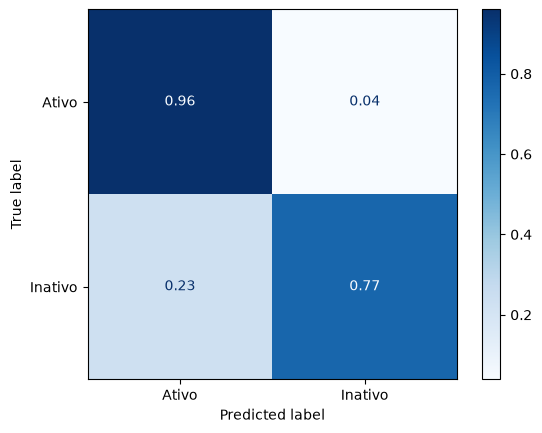

In [17]:
ConfusionMatrixDisplay.from_estimator(
    modelo_arvore, X_teste, y_teste,
    normalize='true', cmap='Blues'
);

Curva ROC

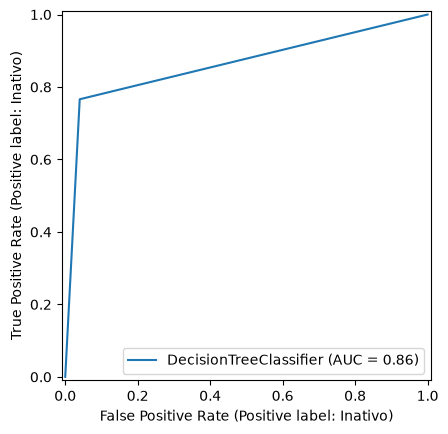

In [18]:
RocCurveDisplay.from_estimator(
    modelo_arvore, X_teste, y_teste,
    pos_label='Inativo'
);

4.2 Floresta Aleatória

In [19]:
modelo_rf = RandomForestClassifier(random_state=RANDOM_STATE)

# Ajusta o classificador ao conjunto de treinamento
modelo_rf.fit(X_treino, y_treino)

# Prevê o Target do conjunto de teste
predicoes_rf = modelo_rf.predict(X_teste)

Acurácia nos conjuntos de treino e teste (2)

In [20]:
predicoes_rf_treino = modelo_rf.predict(X_treino)

acuracia_rf_treino = accuracy_score(y_treino, predicoes_rf_treino)
acuracia_rf_teste  = accuracy_score(y_teste, predicoes_rf)

print(f'Acurácia no treino - Random Forest: {acuracia_rf_treino:.2%}')
print(f'Acurácia no teste - Random Forest:  {acuracia_rf_teste:.2%}')

Acurácia no treino - Random Forest: 100.00%
Acurácia no teste - Random Forest:  95.76%


Relatório de classificação - Random Forest

In [21]:
relatorio_rf = classification_report(y_teste, predicoes_rf)
print(relatorio_rf)

              precision    recall  f1-score   support

       Ativo       0.96      0.99      0.98      1701
     Inativo       0.95      0.78      0.85       325

    accuracy                           0.96      2026
   macro avg       0.95      0.89      0.91      2026
weighted avg       0.96      0.96      0.96      2026



Matriz de confusão - Random Forest

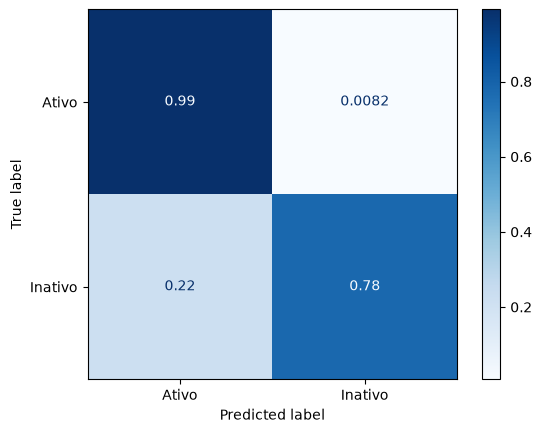

In [22]:
ConfusionMatrixDisplay.from_estimator(
    modelo_rf, X_teste, y_teste,
    normalize='true', cmap='Blues'
);

Curva ROC - Random Forest

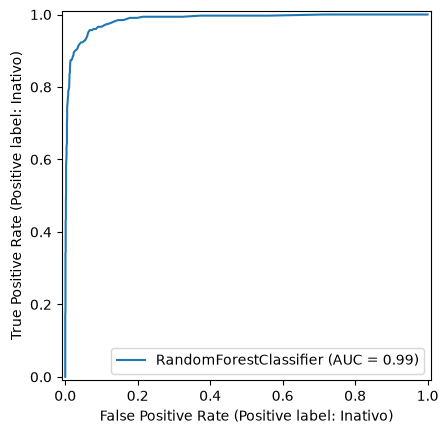

In [23]:
RocCurveDisplay.from_estimator(
    modelo_rf, X_teste, y_teste,
    pos_label='Inativo'
);

Se aumentarmos o número de árvores será que temos uma melhora?

In [24]:
modelo_rf_500 = RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=500)

# Ajusta o classificador ao conjunto de treinamento
modelo_rf_500.fit(X_treino, y_treino)

# Prevê o Target do conjunto de teste
predicoes_rf_500 = modelo_rf_500.predict(X_teste)

Relatório de classificação - Random Forest 500 árvores

In [25]:
relatorio_rf_500 = classification_report(y_teste, predicoes_rf_500)
print(relatorio_rf_500)

              precision    recall  f1-score   support

       Ativo       0.96      0.99      0.98      1701
     Inativo       0.96      0.79      0.86       325

    accuracy                           0.96      2026
   macro avg       0.96      0.89      0.92      2026
weighted avg       0.96      0.96      0.96      2026



5. Ajuste de hiperparâmetros

In [26]:
scorer_recall = make_scorer(recall_score, pos_label='Inativo')

grade_parametros = {
    'n_estimators': [200, 500],
    'max_depth': [None, 15],
    'criterion': ['gini', 'entropy'],
}

modelo_rf_ajuste = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=modelo_rf_ajuste,
    param_grid=grade_parametros,
    cv=5,
    scoring=scorer_recall,          # ← usa o scorer com pos_label
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Recall médio (validação cruzada): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'n_estimators': 500}
Recall médio (validação cruzada): 0.6574


Resultados das combinações testadas, ordenados pelo desempenho médio

In [27]:
colunas_resultado = [
    'param_max_depth',
    'param_criterion',
    'param_n_estimators',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

resultados_cv = (
    pd.DataFrame(grid_search.cv_results_)[colunas_resultado]
    .sort_values('rank_test_score')
    .reset_index(drop=True)
)

resultados_cv

,param_max_depth,param_criterion,param_n_estimators,mean_test_score,std_test_score,rank_test_score
0,None,entropy,500,0.657448,0.306281,1
1,None,gini,500,0.652525,0.299506,2
2,None,gini,200,0.648846,0.297480,3
3,None,entropy,200,0.648223,0.309966,4
4,15,gini,500,0.645144,0.297145,5
5,15,entropy,500,0.644529,0.303081,6
6,15,gini,200,0.640851,0.293342,7
7,15,entropy,200,0.639001,0.300555,8


6. Reavaliando o modelo ajustado

In [28]:
grid_search.best_estimator_

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",7895
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bo

Treinando o modelo com os parâmetros encontrados

In [29]:
modelo_rf_ajustado = clone(grid_search.best_estimator_)
modelo_rf_ajustado.fit(X_treino, y_treino)

predicoes_rf_ajustado = modelo_rf_ajustado.predict(X_teste)

Acurácia nos conjuntos de treino e teste do modelo ajustado

In [30]:
predicoes_rf_treino_ajustado = modelo_rf_ajustado.predict(X_treino)

acuracia_rf_treino_ajustado = accuracy_score(y_treino, predicoes_rf_treino_ajustado)
acuracia_rf_teste_ajustado  = accuracy_score(y_teste, predicoes_rf_ajustado)

print(f'Acurácia no treino: {acuracia_rf_treino_ajustado:.2%}')
print(f'Acurácia no teste:  {acuracia_rf_teste_ajustado:.2%}')

Acurácia no treino: 100.00%
Acurácia no teste:  95.90%


Relatório de classificação do modelo ajustado

In [31]:
print(classification_report(y_teste, predicoes_rf_ajustado))

              precision    recall  f1-score   support

       Ativo       0.96      0.99      0.98      1701
     Inativo       0.95      0.78      0.86       325

    accuracy                           0.96      2026
   macro avg       0.96      0.89      0.92      2026
weighted avg       0.96      0.96      0.96      2026



Matriz de confusão do modelo ajustado

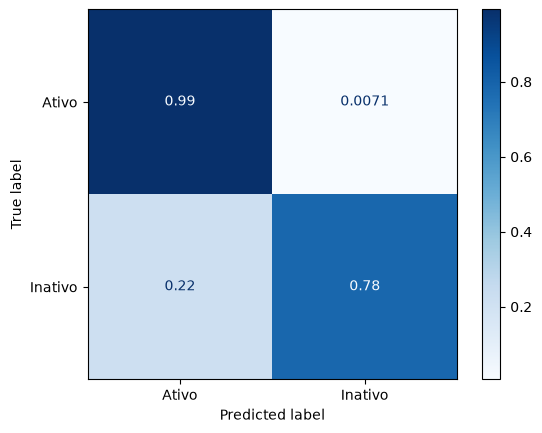

In [32]:
ConfusionMatrixDisplay.from_estimator(
    modelo_rf_ajustado, X_teste, y_teste,
    normalize='true', cmap='Blues'
);

7. Seleção de variáveis (Feature Selection)

7.1 Importância das variáveis

In [33]:
importancias = pd.Series(
    modelo_rf_ajustado.feature_importances_,
    index=X_treino.columns
).sort_values(ascending=False)

importancias

Valor_Total_Transacoes                        0.188781
Quantidade_Total_Transacoes                   0.165518
Saldo_Rotativo_Total                          0.103497
Variacao_Quantidade_Transacoes_T4_T1          0.096076
Variacao_Valor_Transacoes_T4_T1               0.064633
Taxa_Media_Utilizacao_Credito                 0.061391
Quantidade_Produtos_Banco                     0.054429
Limite_Credito                                0.036702
Credito_Disponivel_Medio                      0.036530
Idade_Cliente                                 0.032830
Meses_Inativo_Ultimos_12_Meses                0.026283
Meses_Como_Cliente                            0.025971
Contatos_Ultimos_12_Meses                     0.024019
Numero_Dependentes                            0.013813
Genero_Feminino                               0.006297
Genero_Masculino                              0.006177
Estado_Civil_Casado(a)                        0.005743
Estado_Civil_Solteiro(a)                      0.005046
Escolarida

Visualização das 10 variáveis mais importantes

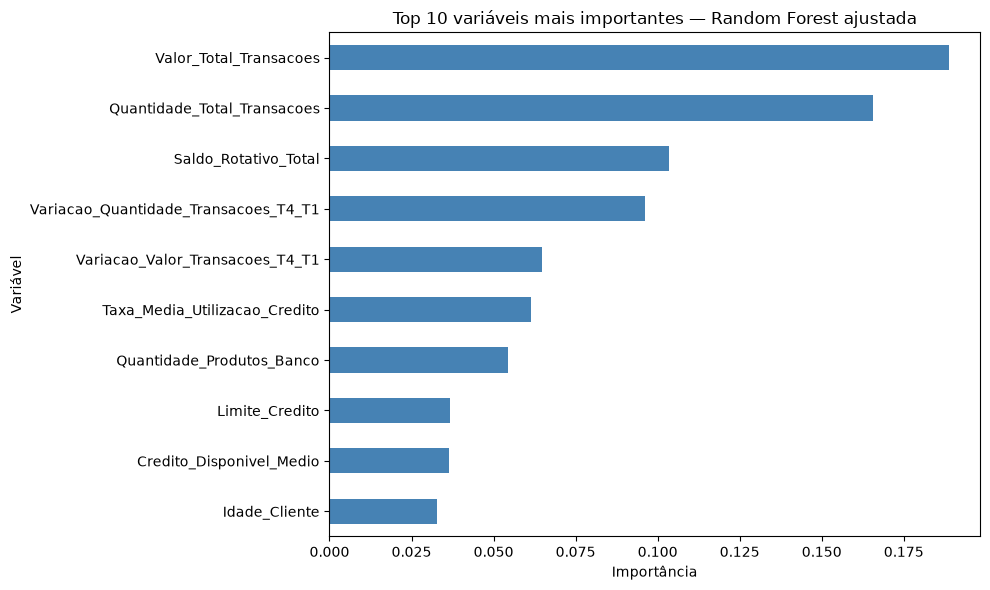

In [34]:
top_10 = importancias.head(10).sort_values()

plt.figure(figsize=(10, 6))
top_10.plot(kind='barh', color='steelblue')

plt.title('Top 10 variáveis mais importantes — Random Forest ajustada')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

7.2 Random Forest treinada apenas com as top-10 features

In [35]:
# 1) Seleciona os nomes das 10 features mais importantes
top10_features = importancias.head(10).index.tolist()
print('Top 10 features selecionadas:')
for i, feat in enumerate(top10_features, start=1):
    print(f'  {i:2d}. {feat}')

# 2) Filtra treino e teste para conter apenas essas colunas
X_treino_top10 = X_treino[top10_features]
X_teste_top10  = X_teste[top10_features]

print(f'\nFormato após seleção: treino {X_treino_top10.shape},teste {X_teste_top10.shape}')

Top 10 features selecionadas:
   1. Valor_Total_Transacoes
   2. Quantidade_Total_Transacoes
   3. Saldo_Rotativo_Total
   4. Variacao_Quantidade_Transacoes_T4_T1
   5. Variacao_Valor_Transacoes_T4_T1
   6. Taxa_Media_Utilizacao_Credito
   7. Quantidade_Produtos_Banco
   8. Limite_Credito
   9. Credito_Disponivel_Medio
  10. Idade_Cliente

Formato após seleção: treino (8101, 10),teste (2026, 10)


3) Cria um NOVO estimador (clone) com a mesma configuração do modelo ajustado

In [36]:
#    Isso preserva o modelo_rf_ajustado intacto para a comparação final.
modelo_rf_fs = clone(grid_search.best_estimator_)

# 4) Treina o novo modelo apenas com as top-10 features
modelo_rf_fs.fit(X_treino_top10, y_treino)

# 5) Previsões
predicoes_rf_fs = modelo_rf_fs.predict(X_teste_top10)

Acurácia com apenas 10 features

In [37]:
predicoes_rf_fs_treino = modelo_rf_fs.predict(X_treino_top10)

acuracia_fs_treino = accuracy_score(y_treino, predicoes_rf_fs_treino)
acuracia_fs_teste  = accuracy_score(y_teste, predicoes_rf_fs)

print(f'Acurácia no treino (top 10): {acuracia_fs_treino:.2%}')
print(f'Acurácia no teste  (top 10): {acuracia_fs_teste:.2%}')

Acurácia no treino (top 10): 100.00%
Acurácia no teste  (top 10): 96.25%


Relatório de classificação do modelo com feature selection

In [38]:
print(classification_report(y_teste, predicoes_rf_fs))

              precision    recall  f1-score   support

       Ativo       0.97      0.99      0.98      1701
     Inativo       0.93      0.83      0.88       325

    accuracy                           0.96      2026
   macro avg       0.95      0.91      0.93      2026
weighted avg       0.96      0.96      0.96      2026



Matriz de confusão do modelo com feature selection

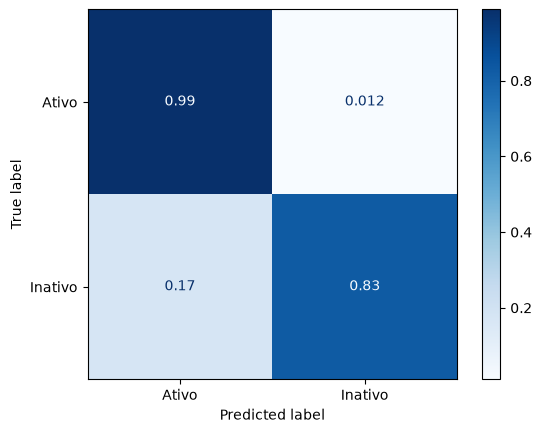

In [39]:
ConfusionMatrixDisplay.from_estimator(
    modelo_rf_fs, X_teste_top10, y_teste,
    normalize='true', cmap='Blues'
);

8. Comparação final entre os modelos

In [40]:
avaliacoes = {
    'Decision Tree': {
        'modelo': modelo_arvore,
        'X_teste': X_teste,
    },
    'Random Forest': {
        'modelo': modelo_rf,
        'X_teste': X_teste,
    },
    'Random Forest ajustado': {
        'modelo': modelo_rf_ajustado,
        'X_teste': X_teste,
    },
    'Random Forest ajustado + Feature Selection': {
        'modelo': modelo_rf_fs,
        'X_teste': X_teste_top10,   # ← conjunto reduzido, específico deste modelo
    },
}

8.1 Curvas ROC comparadas

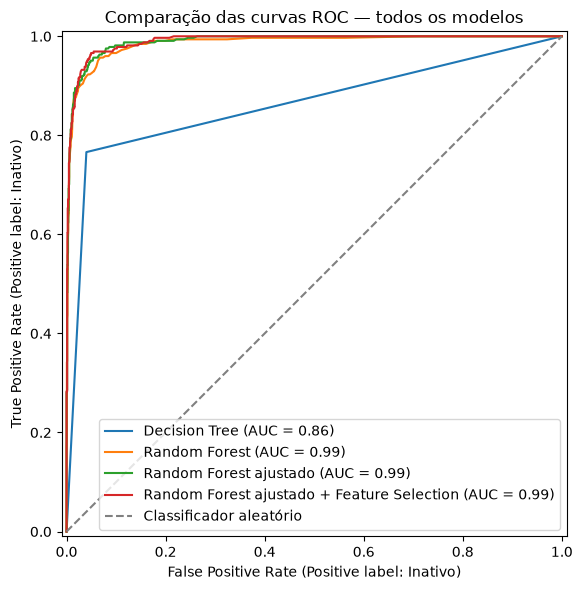

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))

for nome, info in avaliacoes.items():
    RocCurveDisplay.from_estimator(
        info['modelo'],
        info['X_teste'],
        y_teste,
        name=nome,
        pos_label='Inativo',
        ax=ax
    )

ax.plot([0, 1], [0, 1], '--', color='grey', label='Classificador aleatório')
ax.set_title('Comparação das curvas ROC — todos os modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

8.2 Matrizes de confusão comparadas

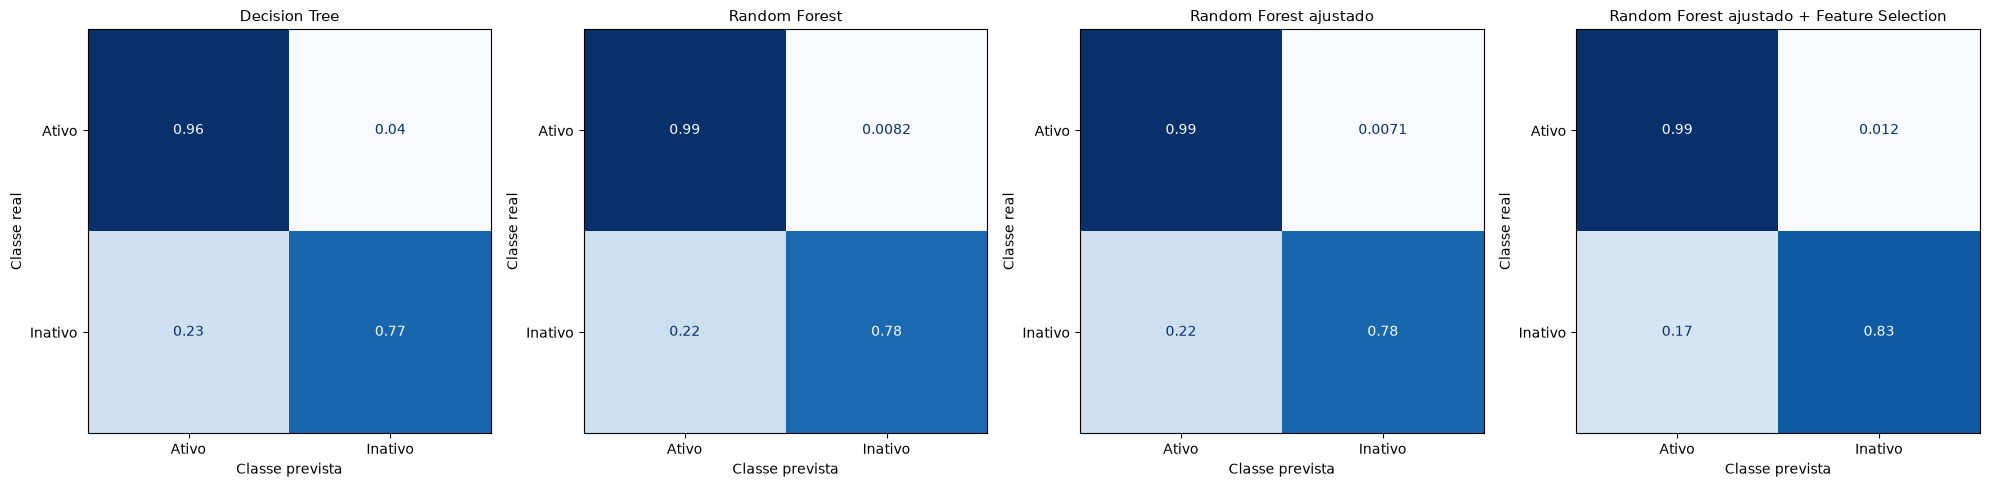

In [42]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (nome, info) in zip(axes, avaliacoes.items()):
    ConfusionMatrixDisplay.from_estimator(
        info['modelo'],
        info['X_teste'],
        y_teste,
        display_labels=info['modelo'].classes_,
        normalize='true',
        cmap='Blues',
        ax=ax,
        colorbar=False
    )
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel('Classe prevista')
    ax.set_ylabel('Classe real')

plt.tight_layout()
plt.show()

8.3 Tabela consolidada de métricas

In [43]:
resultados = []

for nome, info in avaliacoes.items():
    modelo = info['modelo']
    X_avaliar = info['X_teste']

    y_pred = modelo.predict(X_avaliar)
    y_prob = modelo.predict_proba(X_avaliar)[:, list(modelo.classes_).index('Inativo')]

    resultados.append({
        'Modelo': nome,
        'Accuracy':  accuracy_score(y_teste, y_pred),
        'Precision': precision_score(y_teste, y_pred, pos_label='Inativo'),
        'Recall':    recall_score(y_teste, y_pred, pos_label='Inativo'),
        'F1':        f1_score(y_teste, y_pred, pos_label='Inativo'),
        'ROC AUC':   roc_auc_score(y_teste == 'Inativo', y_prob),
    })

df_resultados = pd.DataFrame(resultados).set_index('Modelo').round(3)
df_resultados

,Accuracy,Precision,Recall,F1,ROC AUC
Modelo,,,,,
Decision Tree,0.929,0.785,0.766,0.776,0.863
Random Forest,0.958,0.948,0.778,0.855,0.986
Random Forest ajustado,0.959,0.955,0.782,0.860,0.990
Random Forest ajustado + Feature Selection,0.962,0.931,0.828,0.876,0.990
